In [6]:
import pandas as p

import numpy as np

db = p.read_csv("hotel_reviews_clean.csv")

db.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng,Review_Year,Review_Month,stay_nights,total_review_length
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,...,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,2017,8,6.0,1913
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,...,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,2017,8,4.0,622
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-31,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,...,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968,2017,7,3.0,301
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-31,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,...,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968,2017,7,3.0,1221
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-24,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,...,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968,2017,7,2.0,774


## **Analisi principali confrontate con SQL**

### **Group by mensile**

In [7]:
recensioni_mese = (

    db.groupby(['Review_Year', 'Review_Month'])

      .size()

      .reset_index(name='numero_recensioni')

      .sort_values(['Review_Year', 'Review_Month'])

)

recensioni_mese.head(10)

,Review_Year,Review_Month,numero_recensioni
0,2015,8,19142
1,2015,9,19554
2,2015,10,19309
3,2015,11,17930
4,2015,12,17777
5,2016,1,19343
6,2016,2,18767
7,2016,3,20619
8,2016,4,21354
9,2016,5,22921


L’analisi raggruppa le recensioni in base all’anno e al mese di pubblicazione, calcolando il numero totale di recensioni per ciascun periodo. Dai primi risultati si osserva che il dataset contiene recensioni a partire da agosto 2015. Nei mesi visualizzati, il volume delle recensioni resta piuttosto elevato, con valori compresi tra circa 17.700 e 22.900 recensioni mensili.

Questa analisi permette di osservare l’andamento temporale delle recensioni e costituisce una base utile per individuare eventuali periodi con maggiore o minore attività da parte dei recensori.

### **Ranking nazionalità**

In [8]:
ranking_nazionalita = (

    db.groupby('Reviewer_Nationality')['Reviewer_Score']

      .agg(numero_recensioni='count', score_medio='mean')

      .reset_index()

      .sort_values('numero_recensioni', ascending=False)

)

ranking_nazionalita.head(10)

,Reviewer_Nationality,numero_recensioni,score_medio
214,United Kingdom,244321,8.486302
216,United States of America,35108,8.788285
14,Australia,21502,8.592229
98,Ireland,14733,8.463056
213,United Arab Emirates,10170,7.882616
176,Saudi Arabia,8903,7.884938
144,Netherlands,8691,8.127062
197,Switzerland,8607,8.160892
78,Germany,7831,8.133840
38,Canada,7802,8.546180


L’analisi raggruppa le recensioni per nazionalità del recensore, calcolando il numero totale di recensioni e lo score medio. Il Regno Unito risulta la nazionalità più rappresentata, con 244.321 recensioni e uno score medio di 8,49. Seguono Stati Uniti e Australia, che presentano meno recensioni ma score medi leggermente più alti. Come si può notare dall'analisi, le nazionalità più presenti assegnano punteggi medi generalmente elevati, ma con alcune differenze tra i gruppi. Questa analisi è utile per capire quali paesi contribuiscono maggiormente alle recensioni e come varia la percezione degli hotel in base alla provenienza dei recensori.

### **Distribuzione città**

Come primo passaggio, viene ricavata la città a partire dalla colonna Hotel_Address, creando una nuova colonna chiamata city

In [9]:
def estrai_city(address):
    if 'London' in address:
        return 'London'
    elif 'Paris' in address:
        return 'Paris'
    elif 'Barcelona' in address:
        return 'Barcelona'
    elif 'Amsterdam' in address:
        return 'Amsterdam'
    elif 'Vienna' in address:
        return 'Vienna'
    elif 'Milan' in address:
        return 'Milan'
    else:
        return 'Altra citta'

db['city'] = db['Hotel_Address'].apply(estrai_city)
print(db[['Hotel_Address', 'city']].head(10))

                                       Hotel_Address       city
0   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...  Amsterdam
1   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...  Amsterdam
2   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...  Amsterdam
3   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...  Amsterdam
4   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...  Amsterdam
5   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...  Amsterdam
6   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...  Amsterdam
7   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...  Amsterdam
8   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...  Amsterdam
9   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...  Amsterdam


Come secondo passaggio, è stata calcolata la distribuzione del numero di recensioni per città

In [10]:
distribuzione_citta = (

    db.groupby('city')

      .size()

      .reset_index(name='numero_recensioni')

      .sort_values('numero_recensioni', ascending=False)

)

distribuzione_citta

,city,numero_recensioni
2,London,262298
1,Barcelona,59942
4,Paris,59031
0,Amsterdam,57211
3,Milan,37204
5,Vienna,36258


Dalla tabella si può confermare che Londra è nettamente la città con il maggior numero di recensioni, ammontano a 262.298, rispetto a tutte le altre città presenti nel dataset.

Seguono Barcellona, Parigi e Amsterdam, che presentano valori molto simili tra loro, intorno alle 57.000-60.000 recensioni. Milano e Vienna registrano invece un numero inferiore di recensioni, rispettivamente 37.204 e 36.258.

## **Feautures engineering minimo**

### Sentiment base da word counts

In [11]:
db['sentiment_balance'] = (

    db['Review_Total_Positive_Word_Counts'] - db['Review_Total_Negative_Word_Counts']

)
print(db[['Review_Total_Positive_Word_Counts',

          'Review_Total_Negative_Word_Counts',

          'sentiment_balance']].head(10))

   Review_Total_Positive_Word_Counts  Review_Total_Negative_Word_Counts  \
0                                 11                                397   
1                                105                                  0   
2                                 21                                 42   
3                                 26                                210   
4                                  8                                140   
5                                 20                                 17   
6                                 18                                 33   
7                                 19                                 11   
8                                  0                                 34   
9                                 50                                 15   

   sentiment_balance  
0               -386  
1                105  
2                -21  
3               -184  
4               -132  
5                  3  
6            

È stata creata la variabile sentiment_balance, calcolata come differenza tra il numero di parole positive e il numero di parole negative presenti nella recensione. Valori positivi indicano una prevalenza di contenuti positivi, mentre valori negativi indicano una maggiore presenza di termini negativi. Questa variabile consente di ottenere una misura sintetica del tono della recensione.

Per arricchire l’analisi è stata costruita una variabile derivata denominata sentiment_balance, ottenuta sottraendo il conteggio delle parole negative dal conteggio delle parole positive. In questo modo ogni recensione viene rappresentata da un indicatore numerico sintetico del tono espresso: valori elevati segnalano una recensione più positiva, valori molto negativi una recensione più critica, mentre valori prossimi allo zero suggeriscono un equilibrio tra aspetti positivi e negativi.

### Calcolo lo score medio per città

In [12]:
city_score = (

    db.groupby('city')['Reviewer_Score']

      .mean()

      .reset_index(name='score_medio')

)

print(city_score)

        city  score_medio
0  Amsterdam     8.456230
1  Barcelona     8.553839
2     London     8.324130
3      Milan     8.346678
4      Paris     8.423113
5     Vienna     8.567158


È stato calcolato lo score_medio per ciascuna città raggruppando le recensioni in base alla variabile city. I risultati mostrano che Vienna e Barcellona presentano i valori medi più elevati, mentre Londra e Milano registrano score medi inferiori. A partire da questi valori è stata introdotta una nuova variabile categoriale, cluster_score, con l’obiettivo di segmentare le città in gruppi di performance (basso, medio, alto) e rendere più immediato il confronto geografico.

### Cluster città per score

In [13]:
city_score['cluster_score'] = p.cut(

    city_score['score_medio'],

    bins=[0, 8.35, 8.5, 10],

    labels=['basso', 'medio', 'alto']

)

print(city_score)

        city  score_medio cluster_score
0  Amsterdam     8.456230         medio
1  Barcelona     8.553839          alto
2     London     8.324130         basso
3      Milan     8.346678         basso
4      Paris     8.423113         medio
5     Vienna     8.567158          alto


È stata inoltre creata una segmentazione delle città in base allo score medio delle recensioni. Le città sono state raggruppate in cluster di performance (basso, medio, alto) per facilitare il confronto geografico e sintetizzare i risultati.

## **Visualizzazioni con Matplotlib**

In [15]:
import matplotlib.pyplot as plt 

In [16]:
import seaborn as sns

In [17]:
def categoria_score(score):

    if score < 5:

        return 'Basso'

    elif score < 8:

        return 'Medio'

    else:

        return 'Alto'

In [18]:
db['categoria_score'] = db['Reviewer_Score'].apply(categoria_score)

In [19]:
print(db[['Reviewer_Score', 'categoria_score']].head(10))

   Reviewer_Score categoria_score
0             2.9           Basso
1             7.5           Medio
2             7.1           Medio
3             3.8           Basso
4             6.7           Medio
5             6.7           Medio
6             4.6           Basso
7            10.0            Alto
8             6.5           Medio
9             7.9           Medio


Dai primi risultati si osserva che i punteggi più bassi, come 2.9, 3.8 e 4.6, vengono classificati nella categoria “Basso”, mentre i valori intermedi, come 6.7, 7.1, 7.5 e 7.9, rientrano nella categoria “Medio”. Il punteggio massimo, pari a 10.0, viene invece classificato come “Alto”.

## **Line plot recensioni per mese**

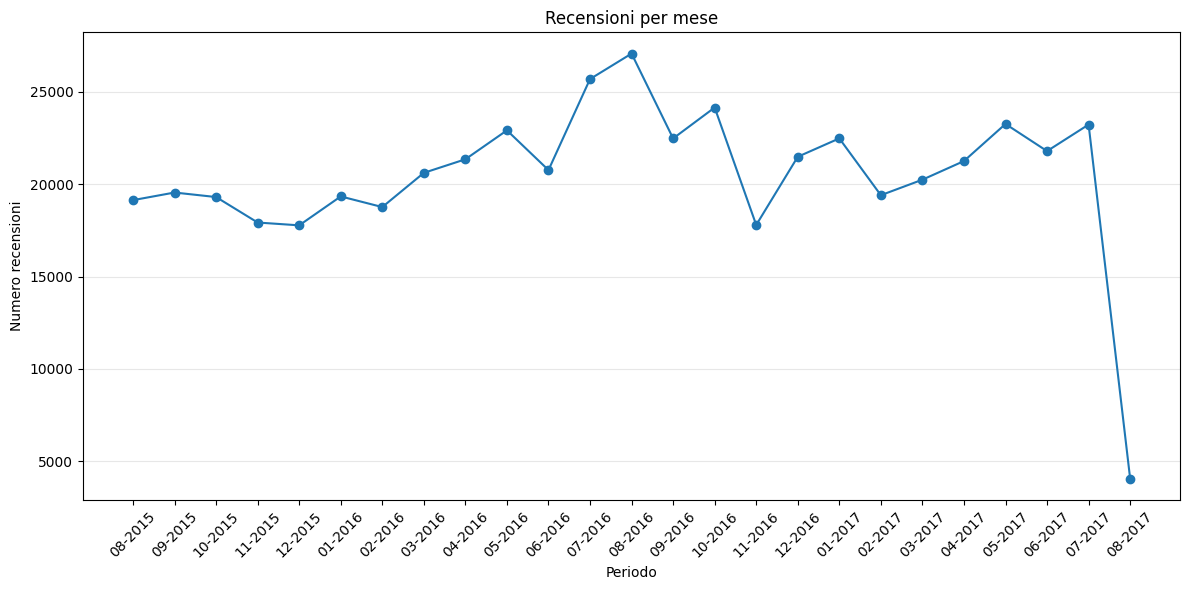

In [20]:
recensioni_mensili = (

    db.groupby(['Review_Year', 'Review_Month'])

      .size()

      .reset_index(name='numero_recensioni')

      .sort_values(['Review_Year', 'Review_Month'])

)

recensioni_mensili['periodo'] = (

    recensioni_mensili['Review_Month'].astype(str).str.zfill(2) + '-' +
    
    recensioni_mensili['Review_Year'].astype(str)
)

plt.figure(figsize=(12,6))

plt.plot(recensioni_mensili['periodo'], recensioni_mensili['numero_recensioni'], marker='o')

plt.title('Recensioni per mese')

plt.xlabel('Periodo')

plt.ylabel('Numero recensioni')

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig('grafico_1_recensioni_mese.png', dpi=300, bbox_inches='tight')

plt.show()

La linea evidenzia un volume di recensioni generalmente elevato e abbastanza stabile, con valori che nella maggior parte dei mesi si collocano tra circa 18.000 e 24.000 recensioni.

## **Line plot recensioni per anno**

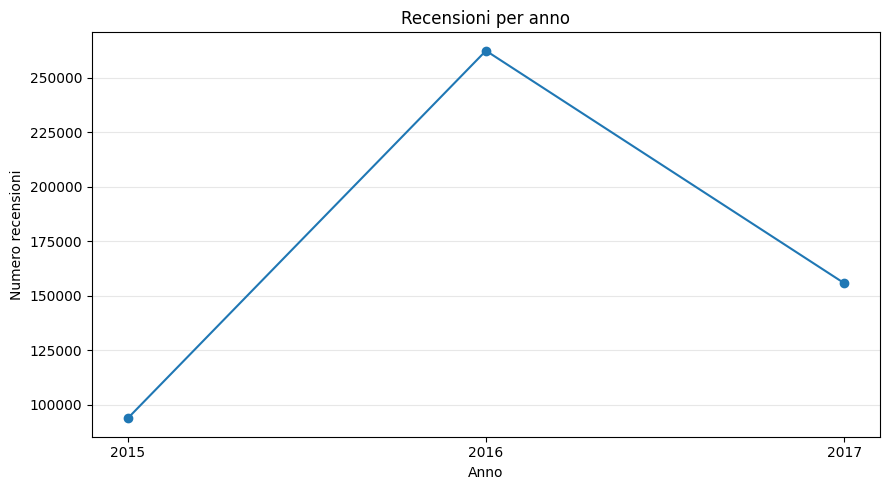

In [21]:
recensioni_annuali = (
    db.groupby('Review_Year')
      .size()
      .reset_index(name='numero_recensioni')
      .sort_values('Review_Year')
)
plt.figure(figsize=(9,5))
plt.plot(recensioni_annuali['Review_Year'], recensioni_annuali['numero_recensioni'], marker='o')
plt.title('Recensioni per anno')
plt.xlabel('Anno')
plt.ylabel('Numero recensioni')
plt.xticks(recensioni_annuali['Review_Year'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_2_recensioni_anno.png', dpi=300, bbox_inches='tight')
plt.show()

Il grafico delle recensioni per anno evidenzia un andamento non uniforme nel periodo osservato. Il numero di recensioni cresce nettamente dal 2015 al 2016, anno in cui si registra il picco massimo, per poi diminuire nel 2017. Questo andamento suggerisce una forte concentrazione delle recensioni nel 2016, mentre il 2015 e il 2017 presentano volumi inferiori. La dinamica può dipendere sia dalla distribuzione temporale del dataset sia da una diversa intensità di raccolta delle recensioni nei tre anni considerati.

## **Bar chart top 10 nazionalità per recensioni**

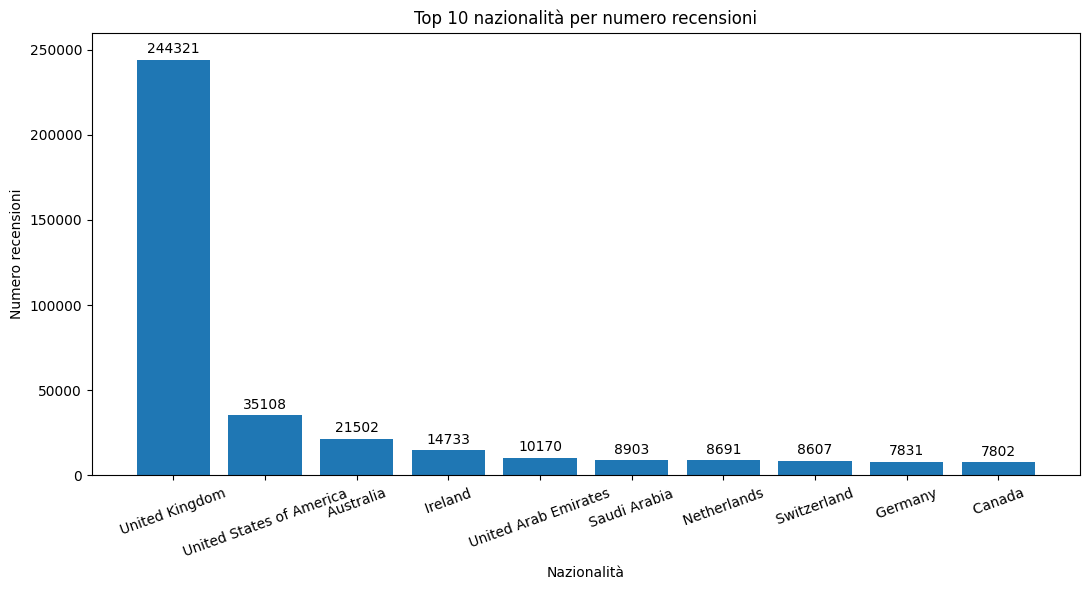

In [26]:
top10_naz = (

    db.groupby('Reviewer_Nationality')

      .size()

      .reset_index(name='numero_recensioni')

      .sort_values('numero_recensioni', ascending=False)

      .head(10)

)

plt.figure(figsize=(11,6))

bars = plt.bar(top10_naz['Reviewer_Nationality'], top10_naz['numero_recensioni'])

plt.title('Top 10 nazionalità per numero recensioni')

plt.xlabel('Nazionalità')

plt.ylabel('Numero recensioni')

plt.xticks(rotation=20)

plt.ylim(0, 260000)

for bar in bars:

    yval = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        yval + 2000,

        int(yval),

        ha='center',

        va='bottom'

    )

plt.tight_layout()

plt.show()

Il bar chart delle top 10 nazionalità per numero di recensioni mostra una forte concentrazione delle review nel gruppo dei recensori del Regno Unito, che risulta nettamente predominante rispetto a tutte le altre nazionalità.Le altre nazionalità, come Irlanda, Emirati Arabi Uniti, Arabia Saudita, Paesi Bassi, Svizzera, Germania e Canada, presentano valori più contenuti e relativamente ravvicinati, segnalando una presenza meno dominante ma comunque significativa.

## **Bar chart top 10 città per numero recensioni**

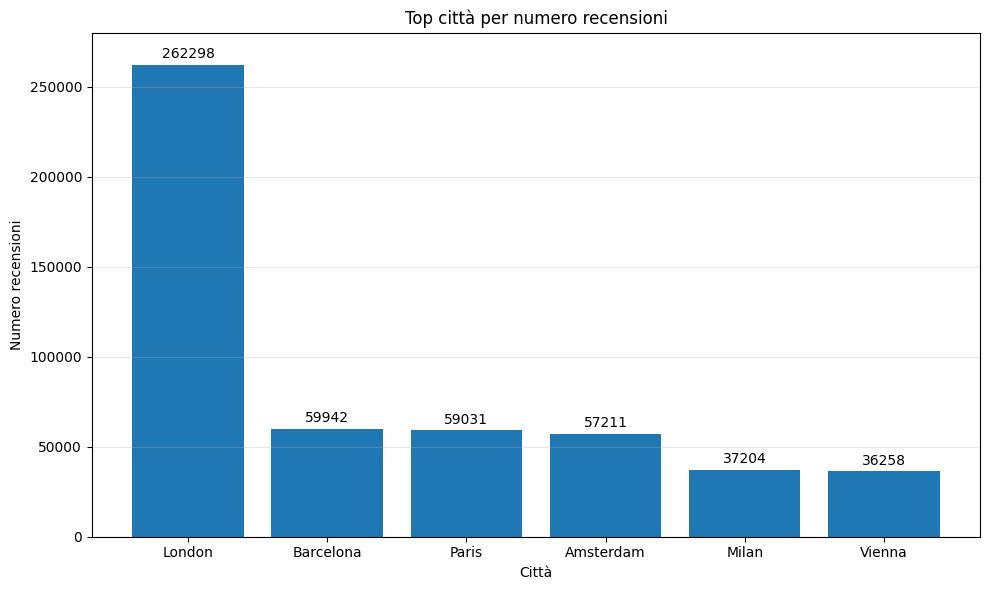

In [27]:
top_citta = (
    db.groupby('city')
      .size()
      .reset_index(name='numero_recensioni')
      .sort_values('numero_recensioni', ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
bars = plt.bar(top_citta['city'], top_citta['numero_recensioni'])

plt.title('Top città per numero recensioni')
plt.xlabel('Città')
plt.ylabel('Numero recensioni')
plt.ylim(0, 280000)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 2000,
        int(yval),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Il grafico evidenzia una forte concentrazione delle recensioni su Londra, che domina nettamente rispetto alle altre città. Barcellona, Parigi e Amsterdam presentano volumi intermedi e abbastanza vicini tra loro, mentre Milano e Vienna si collocano su valori più bassi. Nel complesso, il dataset appare quindi fortemente sbilanciato verso la città di Londra.

## **Box plot distribuzione Reviewer Score per nazionalità top 3**


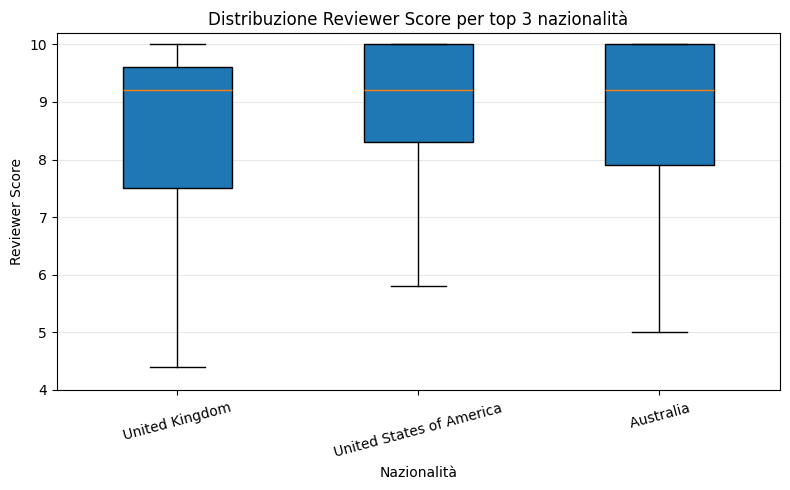

In [28]:
top3_naz = (
    db['Reviewer_Nationality']
    .value_counts()
    .head(3)
    .index
)

db_top3 = db[db['Reviewer_Nationality'].isin(top3_naz)]

data_box = [
    db_top3[db_top3['Reviewer_Nationality'] == naz]['Reviewer_Score']
    for naz in top3_naz
]

plt.figure(figsize=(8,5))
plt.boxplot(
    data_box,
    tick_labels=top3_naz,
    patch_artist=True,
    widths=0.45,
    showfliers=False
)

plt.title('Distribuzione Reviewer Score per top 3 nazionalità')
plt.xlabel('Nazionalità')
plt.ylabel('Reviewer Score')
plt.ylim(4, 10.2)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('grafico_5_boxplot_top3_nazionalita.png', dpi=300, bbox_inches='tight')
plt.show()

Il box plot confronta la distribuzione dei Reviewer Score per le tre nazionalità più rappresentate nel dataset: United Kingdom, United States of America e Australia. In tutti e tre i gruppi la mediana dei punteggi risulta elevata, collocandosi oltre il valore 9, a indicare una generale tendenza a recensioni positive.

Le tre distribuzioni mostrano tuttavia alcune differenze. Australia e United States of America presentano mediane leggermente più alte e una concentrazione dei punteggi prevalentemente nella fascia alta della scala, mentre il Regno Unito mostra una maggiore estensione verso valori più bassi. Questo suggerisce che i recensori britannici, pur assegnando anch’essi punteggi mediamente elevati, presentano una variabilità leggermente maggiore rispetto agli altri due gruppi. Il grafico conferma che le tre principali nazionalità tendono a esprimere valutazioni generalmente positive, ma evidenzia anche una diversa dispersione degli score, elemento utile per approfondire il comportamento valutativo dei diversi gruppi di recensori.

## **Histogram Review Length per categoria score**

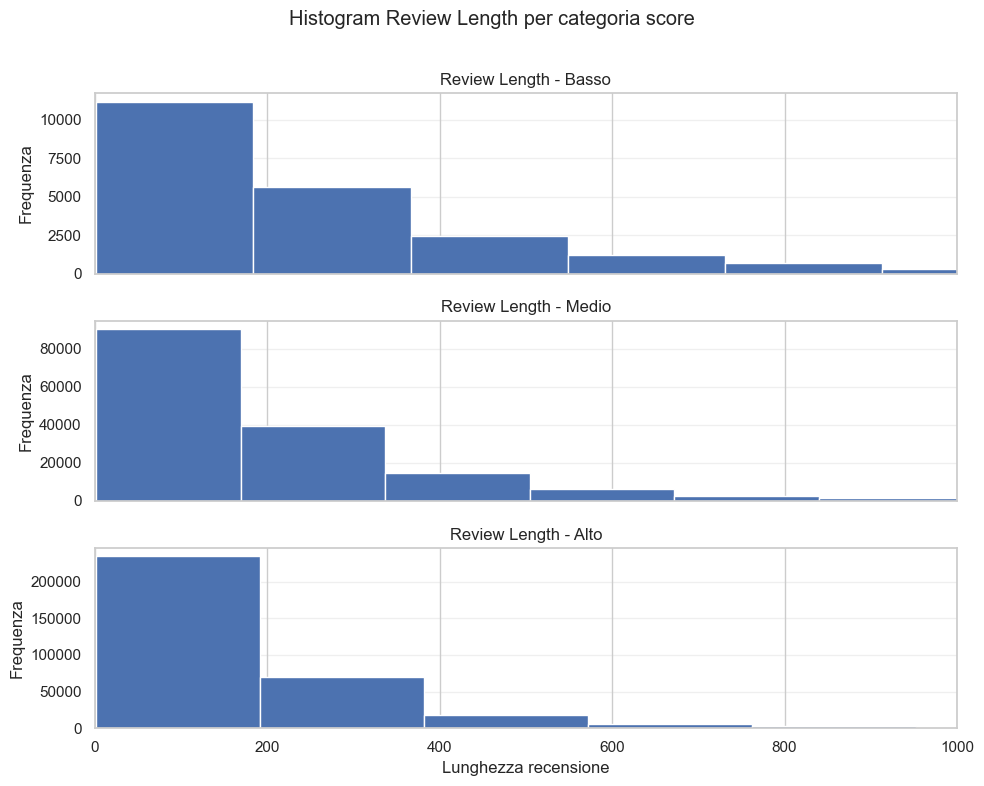

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(10,8), sharex=True)

categorie = ['Basso', 'Medio', 'Alto']

for ax, cat in zip(axes, categorie):

    subset = db[db['categoria_score'] == cat]['total_review_length']

    ax.hist(subset, bins=20)

    ax.set_title(f'Review Length - {cat}')

    ax.set_ylabel('Frequenza')

    ax.set_xlim(0, 1000)

    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Histogram Review Length per categoria score')

axes[-1].set_xlabel('Lunghezza recensione')

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig('grafico_6_hist_review_length_categoria_score.png', dpi=300, bbox_inches='tight')

plt.show()

I tre istogrammi mostrano la distribuzione della lunghezza delle recensioni nelle categorie di score basso, medio e alto. In tutti i gruppi la maggior parte delle recensioni si concentra su lunghezze contenute, mentre le recensioni molto lunghe risultano meno frequenti. 

Il grafico evidenzia che la lunghezza delle recensioni tende a concentrarsi su valori bassi o medi in tutte le categorie di punteggio. Solo una quota ridotta di recensioni raggiunge lunghezze elevate, generando una distribuzione asimmetrica verso destra.

## **Scatter plot Review Length vs Reviewer Score**

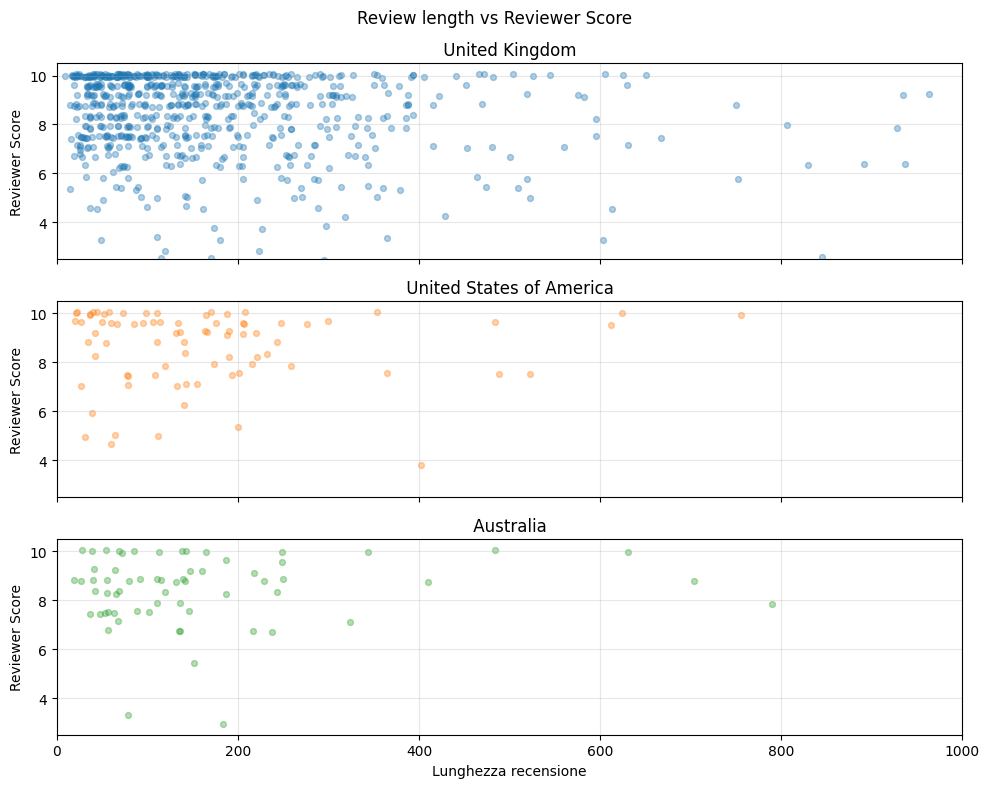

In [40]:
sample_db = db.sample(1500, random_state=42)

top3_naz_scatter = (
    sample_db['Reviewer_Nationality']
    .value_counts()
    .head(3)
    .index
)

sample_db = sample_db[sample_db['Reviewer_Nationality'].isin(top3_naz_scatter)].copy()

sample_db['Reviewer_Score_jitter'] = (
    sample_db['Reviewer_Score'] + np.random.uniform(-0.08, 0.08, len(sample_db))
)

fig, axes = plt.subplots(3, 1, figsize=(10,8), sharex=True, sharey=True)

colori = ['tab:blue', 'tab:orange', 'tab:green']

for ax, naz, colore in zip(axes, top3_naz_scatter, colori):
    subset = sample_db[sample_db['Reviewer_Nationality'] == naz]
    ax.scatter(
        subset['total_review_length'],
        subset['Reviewer_Score_jitter'],
        alpha=0.35,
        s=18,
        color=colore
    )
    ax.set_title(naz)
    ax.set_ylabel('Reviewer Score')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Lunghezza recensione')
fig.suptitle('Review length vs Reviewer Score')
plt.xlabel('Lunghezza recensione')
plt.ylabel('Reviewer Score')
plt.xlim(0, 1000)
plt.ylim(2.5, 10.5)
plt.tight_layout()
plt.savefig('grafico_7_scatter_review_length_vs_score.png', dpi=300, bbox_inches='tight')
plt.show()

Il grafico scatter evidenzia che la maggior parte delle recensioni ha una lunghezza contenuta o intermedia, mentre i punteggi risultano prevalentemente alti. Non emerge una relazione lineare forte tra lunghezza della recensione e Reviewer Score: recensioni brevi e lunghe possono infatti associarsi sia a valutazioni positive sia a valutazioni più basse. Il Regno Unito presenta il numero più elevato di osservazioni, confermando il suo peso dominante nel dataset.

## **Bar chart score medio per top 10 città**

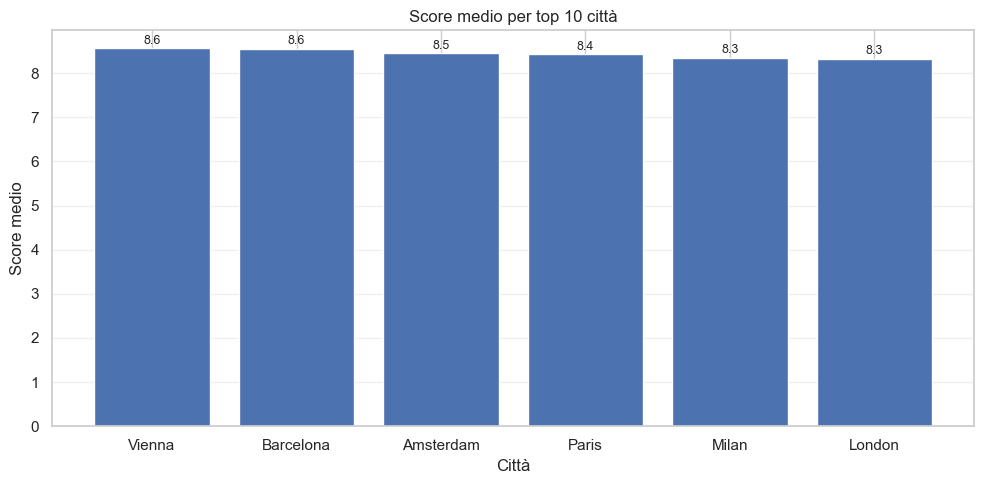

In [40]:
score_citta = (
    db.groupby('city')['Reviewer_Score']
      .mean()
      .reset_index(name='score_medio')
      .sort_values('score_medio', ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

bars = plt.bar(score_citta['city'], score_citta['score_medio'])

plt.title('Score medio per top 10 città')
plt.xlabel('Città')
plt.ylabel('Score medio')
plt.grid(axis='y', alpha=0.3)

plt.ylim(0, score_citta['score_medio'].max() + 0.4)

for bar, valore in zip(bars, score_citta['score_medio']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        valore + 0.03,
        f'{valore:.1f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('grafico_score_medio_top10_citta.png', dpi=300, bbox_inches='tight')
plt.show()

Il grafico dello score medio per top 10 città evidenzia differenze contenute ma visibili tra le città del dataset. Vienna risulta la città con lo score medio più elevato, seguita da Barcelona e Amsterdam, mentre Milan e soprattutto London presentano valori medi leggermente inferiori. Nel complesso, i punteggi medi risultano comunque alti per tutte le città considerate, segnalando una percezione generalmente positiva delle strutture alberghiere analizzate.

## **Heatmap correlazioni numeriche**

In questa sezione viene analizzata la correlazione tra le principali variabili numeriche del dataset, con l’obiettivo di individuare eventuali relazioni positive o negative tra punteggi, lunghezza delle recensioni, conteggi di parole e tempo trascorso dalla pubblicazione della recensione. La heatmap consente di visualizzare in modo sintetico l’intensità di tali relazioni ed è uno dei grafici richiesti nella consegna.

Prima di costruire la matrice di correlazione, la variabile days_since_review viene trasformata in formato numerico. Questo passaggio è necessario perché la correlazione può essere calcolata solo su variabili quantitative.

In [49]:
db['days_since_review_num'] = (

    db['days_since_review']

      .str.extract(r'(\d+)')

      .astype(float)

)

Successivamente vengono selezionate le principali colonne numeriche da includere nell’analisi: i punteggi del recensore e dell’hotel, i conteggi di parole positive e negative, la lunghezza totale della recensione e il numero di giorni trascorsi dalla recensione. Su queste variabili viene poi calcolata la matrice di correlazione.

In [50]:
corr_cols = [
    'Reviewer_Score',
    'Average_Score',
    'Review_Total_Positive_Word_Counts',
    'Review_Total_Negative_Word_Counts',
    'total_review_length',
    'days_since_review_num'
]

corr_matrix = db[corr_cols].corr()

La heatmap permette di osservare visivamente la forza delle correlazioni tra le variabili considerate. Valori più vicini a 1 indicano una correlazione positiva, valori vicini a -1 indicano una correlazione negativa, mentre valori prossimi a 0 segnalano una relazione debole o assente.

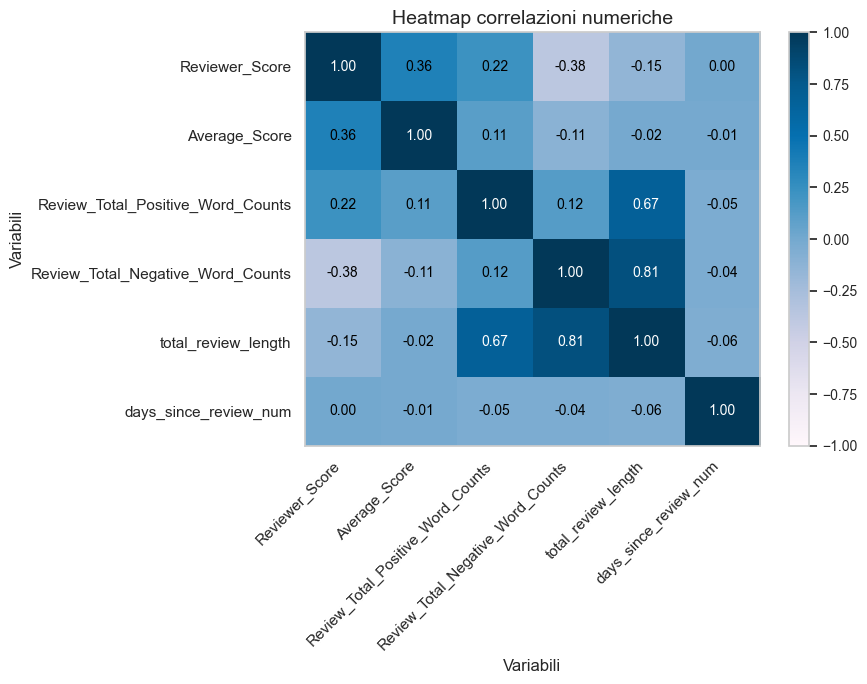

In [51]:
db['days_since_review_num'] = (
    db['days_since_review']
    .str.extract(r'(\d+)')
    .astype(float)
)

corr_cols = [
    'Reviewer_Score',
    'Average_Score',
    'Review_Total_Positive_Word_Counts',
    'Review_Total_Negative_Word_Counts',
    'total_review_length',
    'days_since_review_num'
]

corr_matrix = db[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    corr_matrix,
    cmap='PuBu',          
    vmin=-1,
    vmax=1,
    interpolation='nearest',
    aspect='auto'
)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=10)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

ax.set_title('Heatmap correlazioni numeriche', fontsize=14)
ax.set_xlabel('Variabili')
ax.set_ylabel('Variabili')

ax.grid(False)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        valore = corr_matrix.iloc[i, j]
        colore_testo = 'black'
        if valore > 0.65:
            colore_testo = 'white'
        ax.text(
            j, i,
            f'{valore:.2f}',
            ha='center',
            va='center',
            color=colore_testo,
            fontsize=10
        )

plt.tight_layout()
plt.savefig('grafico_heatmap_correlazioni_numeriche.png', dpi=300, bbox_inches='tight')
plt.show()

La heatmap delle correlazioni numeriche evidenzia le relazioni tra le principali variabili quantitative del dataset. La diagonale principale presenta valore massimo, in quanto ogni variabile è perfettamente correlata con sé stessa. Tra le correlazioni più rilevanti si osservano relazioni positive tra la lunghezza della recensione e i conteggi di parole positive e negative, segnalando che recensioni più lunghe tendono a contenere un numero maggiore di termini. Le relazioni che coinvolgono Reviewer_Score e Average_Score risultano invece più moderate, mentre days_since_review_num mostra correlazioni deboli con le altre variabili. Nel complesso, la heatmap suggerisce che la struttura testuale delle recensioni è più fortemente associata alla loro lunghezza che non ai punteggi assegnati.